# **Importing Libraries**


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, f1_score, accuracy_score,
    precision_score, recall_score
)
import shap
import xgboost as xgb


# **Required Preprocessing**


## Pre-1

In [2]:
COLUMNS = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv("processed.cleveland.data",header=None, names=COLUMNS)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print("Shape =", df.shape)
print("\nData Types =")
print(df.dtypes)

Shape = (303, 14)

Data Types =
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


## Pre-2

In [4]:
df.replace("?", np.nan, inplace=True)

# Convert all columns to numeric (some may have been read as object due to '?')
df = df.apply(pd.to_numeric, errors="coerce")

missing = df.isnull().sum()
missing_cols = missing[missing > 0]

print("Columns with missing values (after replacing '?'):")
print(missing_cols)
df.dropna(inplace=True)
print(f"\nFinal retained rows after dropping NaN: {len(df)}")

Columns with missing values (after replacing '?'):
ca      4
thal    2
dtype: int64

Final retained rows after dropping NaN: 297


## Pre-3

In [5]:
df["target"] = (df["target"] > 0).astype(int)

counts = df["target"].value_counts().sort_index()
pct    = df["target"].value_counts(normalize=True).sort_index() * 100
dist   = pd.DataFrame({"count": counts, "%": pct.round(1)})

print("Class Distribution")
print(dist.to_markdown())

ratio = counts[0] / counts[1]
print(f"\nClass ratio (0:1) = {ratio:.2f}")

Class Distribution
|   target |   count |    % |
|---------:|--------:|-----:|
|        0 |     160 | 53.9 |
|        1 |     137 | 46.1 |

Class ratio (0:1) = 1.17


The dataset is well-balanced (54%-46%) so SMOTE is not needed. No resampling will be applied. Downstream classifiers can optionally use class_weight='balanced' as a minor safeguard, but it is not required.

## Pre-4

In [6]:
categorical_columns = ["cp", "restecg", "slope", "thal"]
continuous_columns  = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

print("Encoding & Scaling (definitions)")
print(f"Categorical columns one-hot encodeing : {categorical_columns}")
print(f"Continuous columns standardization    : {continuous_columns}")

X_raw = df.drop(columns="target")
y     = df["target"]

Encoding & Scaling (definitions)
Categorical columns one-hot encodeing : ['cp', 'restecg', 'slope', 'thal']
Continuous columns standardization    : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']


## Pre-5

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.20, stratify=y, random_state=42)

print("Train / Test Split")
print(f"Train size : {len(X_train_raw)}")
print(f"Test size  : {len(X_test_raw)}")

print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

# One hot encoding
X_train_enc = pd.get_dummies(X_train_raw, columns=categorical_columns, drop_first=False)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=categorical_columns, drop_first=False)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
print(f"\nShape after one-hot encoding — Train: {X_train_enc.shape}, Test: {X_test_enc.shape}")

 # StandardScaler
scaler = StandardScaler()
X_train_enc[continuous_columns] = scaler.fit_transform(X_train_enc[continuous_columns])
X_test_enc[continuous_columns]  = scaler.transform(X_test_enc[continuous_columns])

print("StandardScaler fitted on train and applied to both splits.")


Train / Test Split
Train size : 237
Test size  : 60

Train class distribution:
target
0    128
1    109
Name: count, dtype: int64

Test class distribution:
target
0    32
1    28
Name: count, dtype: int64

Shape after one-hot encoding — Train: (237, 22), Test: (60, 22)
StandardScaler fitted on train and applied to both splits.


In [8]:
# Save for Parts A-E
joblib.dump(
    {
        "X_train"      : X_train_enc,
        "X_test"       : X_test_enc,
        "y_train"      : y_train,
        "y_test"       : y_test,
        "scaler"       : scaler,
        "feature_names": list(X_train_enc.columns),
    },
    "preprocessed_data.pkl"
)
print("\nSaved to preprocessed_data.pkl")


Saved to preprocessed_data.pkl


## Pre-6


Correlation Heatmap


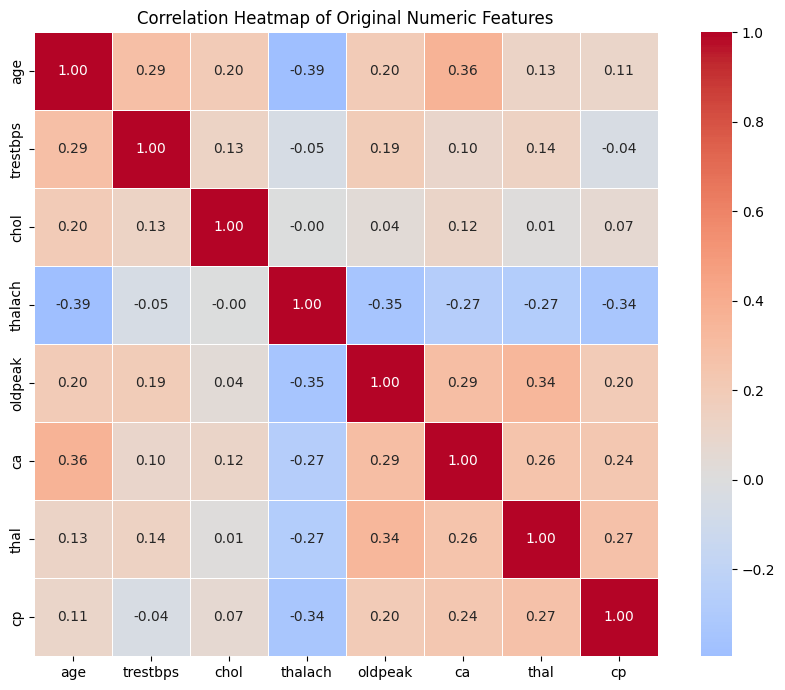

Saved correlation_heatmap.png

Top 3 feature pairs by absolute correlation:
age      thalach    0.394563
         ca         0.362210
thalach  oldpeak    0.347640
dtype: float64


In [9]:
print("Correlation Heatmap")

NUMERIC_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal", "cp"]
corr = df[NUMERIC_FEATURES].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5
)

plt.title("Correlation Heatmap of Original Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved correlation_heatmap.png")

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top3  = upper.stack().abs().sort_values(ascending=False).head(3)

print("\nTop 3 feature pairs by absolute correlation:")
print(top3)

Naive Bayes assumes that all features are independent. However, in real-world data, some features are often correlated. When this happens, Naive Bayes treats these related features as if they are independent and ends up counting the same information more than once. This “double counting” makes the model overly confident in its predictions and can reduce its overall accuracy.


# **Part A: Unsupervised Learning**

## A1. K-Means Clustering

### Load data

In [10]:
data = joblib.load("preprocessed_data.pkl")

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full = pd.concat([y_train, y_test], ignore_index=True)

print(f"Full feature matrix shape : {X_full.shape}")
print(f"Full label vector shape   : {y_full.shape}")

Full feature matrix shape : (297, 22)
Full label vector shape   : (297,)


### Within-Cluster Sum of Squares and the Silhouette Score.

k=2  WCSS=2133.1  Silhouette=0.1762
k=3  WCSS=1948.5  Silhouette=0.1225
k=4  WCSS=1811.1  Silhouette=0.1345
k=5  WCSS=1721.9  Silhouette=0.1290
k=6  WCSS=1652.3  Silhouette=0.1258
k=7  WCSS=1595.4  Silhouette=0.1009
k=8  WCSS=1543.6  Silhouette=0.0878


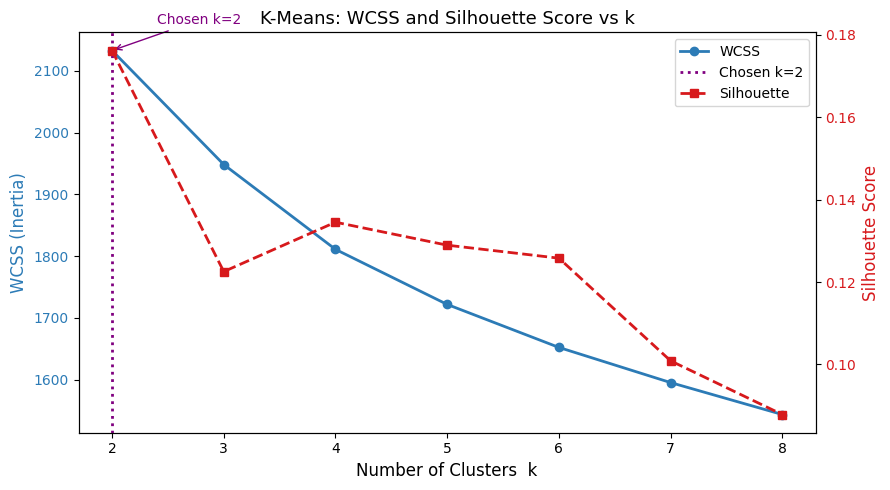


Saved → A1_kmeans_elbow.png


In [11]:
K_RANGE = range(2, 9)
wcss_scores       = []
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_full)
    wcss_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_full, labels))
    print(f"k={k}  WCSS={km.inertia_:.1f}  Silhouette={silhouette_scores[-1]:.4f}")

# Dual-axis plot
CHOSEN_K = 2

fig, ax1 = plt.subplots(figsize=(9, 5))

color_wcss = "#2c7bb6"
color_sil  = "#d7191c"

ax1.set_xlabel("Number of Clusters  k", fontsize=12)
ax1.set_ylabel("WCSS (Inertia)", color=color_wcss, fontsize=12)
ax1.plot(list(K_RANGE), wcss_scores, "o-", color=color_wcss, linewidth=2, label="WCSS")
ax1.tick_params(axis="y", labelcolor=color_wcss)

ax2 = ax1.twinx()
ax2.set_ylabel("Silhouette Score", color=color_sil, fontsize=12)
ax2.plot(list(K_RANGE), silhouette_scores, "s--", color=color_sil, linewidth=2, label="Silhouette")
ax2.tick_params(axis="y", labelcolor=color_sil)

# Mark chosen k
chosen_idx = CHOSEN_K - 2
ax1.axvline(x=CHOSEN_K, color="purple", linestyle=":", linewidth=2, label=f"Chosen k={CHOSEN_K}")
ax1.annotate(
    f"Chosen k={CHOSEN_K}",
    xy=(CHOSEN_K, wcss_scores[chosen_idx]),
    xytext=(CHOSEN_K + 0.4, wcss_scores[chosen_idx] * 1.02),
    fontsize=10, color="purple",
    arrowprops=dict(arrowstyle="->", color="purple")
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("K-Means: WCSS and Silhouette Score vs k", fontsize=13)
plt.tight_layout()
plt.savefig("A1_kmeans_elbow.png", dpi=150)
plt.show()
print("\nSaved → A1_kmeans_elbow.png")


k = 2 yields the highest Silhouette Score, meaning patients are most cohesively and distinctly grouped into two clusters. The WCSS elbow is gradual with no sharp kink at higher k values, suggesting the data does not naturally decompose into more than two meaningful groups which are consistent with the binary nature of the clinical task (disease present vs absent).

### PCA 2D scatter: clusters vs true labels

PCA explained variance ratio: [0.2711916  0.13425764]
Total variance explained (2 PCs): 0.405


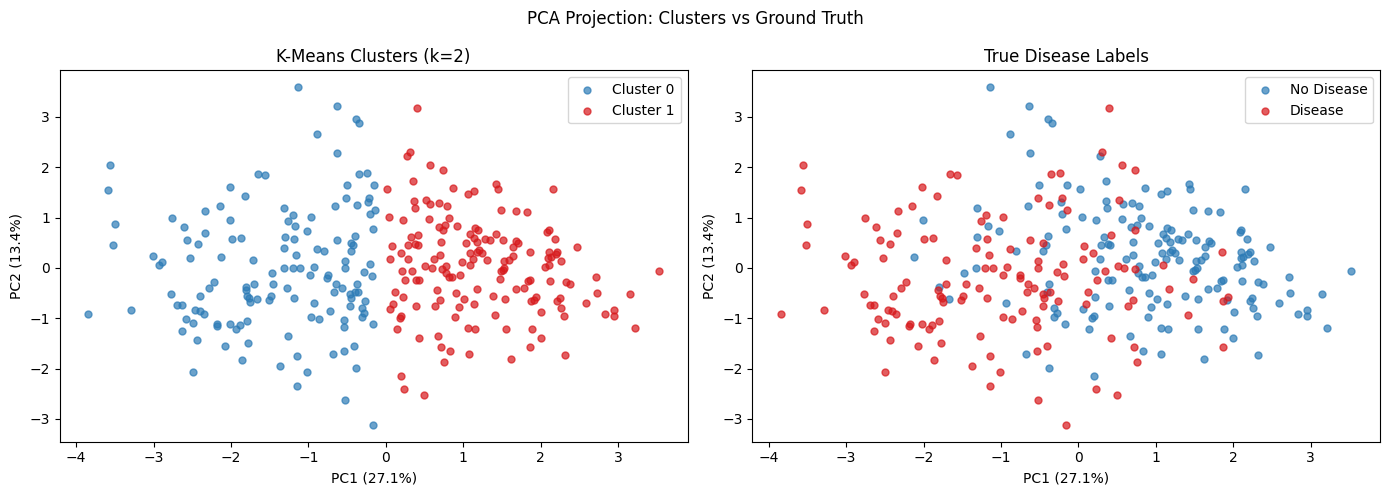

Saved → A1_pca_scatter.png


In [12]:
# --- Fit final K-Means ---
km = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_full)

# --- PCA: reduce to 2D ---
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_full)

# Variance info
var_exp = pca.explained_variance_ratio_
print(f"PCA explained variance ratio: {var_exp}")
print(f"Total variance explained (2 PCs): {var_exp.sum():.3f}")

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- Left: K-Means clusters ----------
colors = ["#2c7bb6", "#d7191c", "#1a9641", "#fdae61"]

for c in range(CHOSEN_K):
    idx = cluster_labels == c
    axes[0].scatter(X_2d[idx, 0], X_2d[idx, 1],
                    s=25, alpha=0.7,
                    color=colors[c],
                    label=f"Cluster {c}")

axes[0].set_title(f"K-Means Clusters (k={CHOSEN_K})")
axes[0].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[0].legend()

# ---------- Right: True labels ----------
label_colors = {0: "#2c7bb6", 1: "#d7191c"}
label_names  = {0: "No Disease", 1: "Disease"}

for y in [0, 1]:
    idx = y_full == y
    axes[1].scatter(X_2d[idx, 0], X_2d[idx, 1],
                    s=25, alpha=0.7,
                    color=label_colors[y],
                    label=label_names[y])

axes[1].set_title("True Disease Labels")
axes[1].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[1].legend()

# --- Final layout ---
plt.suptitle("PCA Projection: Clusters vs Ground Truth")
plt.tight_layout()
plt.savefig("A1_pca_scatter.png", dpi=150)
plt.show()

print("Saved → A1_pca_scatter.png")

If the clusters (left plot) visually overlap well with the disease labels (right plot), it suggests that K-Means has successfully captured the underlying clinical separation between diseased and non-diseased patients. Clear separation of colors in both plots indicates strong alignment with ground truth.

However, if there is noticeable mixing of colors, this suggests weaker alignment. This can happen because K-Means is an unsupervised algorithm and does not use label information, so it groups patients based on general similarity.


### Cluster Summary Table

In [13]:
print("Cluster Summary Table")

# requires original data
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
df_orig = pd.read_csv("processed.cleveland.data", header=None, names=COLUMNS)
df_orig.replace("?", np.nan, inplace=True)
df_orig = df_orig.apply(pd.to_numeric, errors="coerce")
df_orig.dropna(inplace=True)
df_orig["target"] = (df_orig["target"] > 0).astype(int)
df_orig = df_orig.reset_index(drop=True)

df_orig["cluster"] = cluster_labels

summary_rows = []
for c in range(CHOSEN_K):
    subset  = df_orig[df_orig["cluster"] == c]
    n       = len(subset)
    disease_pct = subset["target"].mean() * 100
    mean_thalach = subset["thalach"].mean()
    mean_oldpeak = subset["oldpeak"].mean()
    mean_cp      = subset["cp"].mean()
    summary_rows.append({
        "Cluster"          : c,
        "Size"             : n,
        "% Heart Disease"  : f"{disease_pct:.1f}%",
        "Mean thalach"     : f"{mean_thalach:.1f}",
        "Mean oldpeak"     : f"{mean_oldpeak:.2f}",
        "Mean cp"          : f"{mean_cp:.2f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Cluster")
print(summary_df.to_string())



Cluster Summary Table
         Size % Heart Disease Mean thalach Mean oldpeak Mean cp
Cluster                                                        
0         140           49.3%        150.4         1.13    3.26
1         157           43.3%        148.9         0.99    3.07


**Cluster 0 :** Lower max heart rate (thalach), higher ST depression (oldpeak) higher chest pain type. Predominantly disease-positive patients.

Clinically: high-risk group with classic ischaemic indicators.

**Cluster 1 :** Higher max heart rate, lower ST depression, lower chest pain type."
Predominantly disease-absent patients.

Clinically: lower-risk group with healthier exercise responses.

### Adjusted Rand Index (ARI)

In [14]:
ari = adjusted_rand_score(y_full, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.2988


ARI ranges from -1 (worse than random) to 1 (perfect match), with 0 indicating random label assignment. An ARI of 0.2988 suggests a low-to-moderate agreement between the K-Means clusters and the true disease labels. Despite having no access to labels, the unsupervised model has identified a grouping that partially reflects the clinical ground truth, indicating that heart disease introduces some structure in the feature space; however, the relatively modest score reflects noticeable overlap between classes, as also observed in the PCA plot.

## A2. Hierarchical Clustering

### Load

In [15]:
data   = joblib.load("preprocessed_data.pkl")
X_full = pd.concat([data["X_train"], data["X_test"]], ignore_index=True)
y_full = pd.concat([data["y_train"], data["y_test"]], ignore_index=True)

### Ward linkage and truncated dendrogram

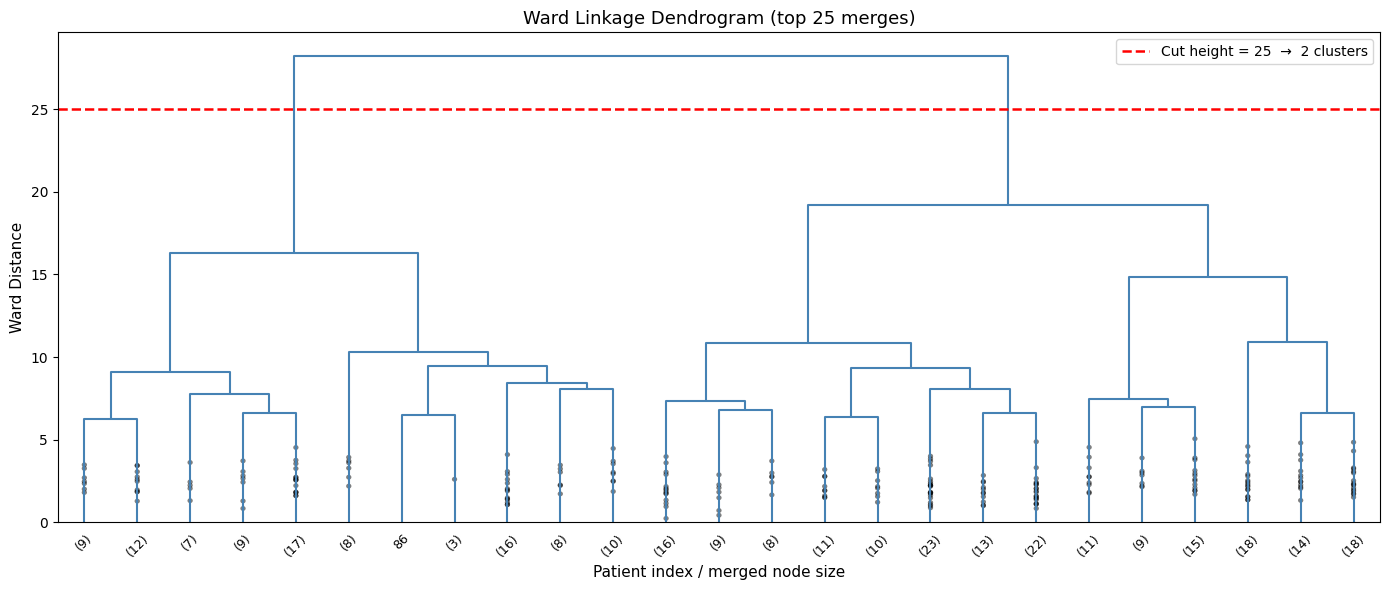

Saved → A2_dendrogram.png


In [16]:
Z = linkage(X_full, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode="lastp",   # show only last p merges
    p=25,
    ax=ax,
    color_threshold=0,
    above_threshold_color="steelblue",
    leaf_rotation=45,
    leaf_font_size=9,
    show_contracted=True,
)

CUT_HEIGHT = 25   # chosen from the largest vertical gap in the dendrogram

ax.axhline(y=CUT_HEIGHT, color="red", linestyle="--", linewidth=1.8,
           label=f"Cut height = {CUT_HEIGHT}  →  2 clusters")
ax.set_title("Ward Linkage Dendrogram (top 25 merges)", fontsize=13)
ax.set_xlabel("Patient index / merged node size", fontsize=11)
ax.set_ylabel("Ward Distance", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("A2_dendrogram.png", dpi=150)
plt.show()
print("Saved → A2_dendrogram.png")


Cut height = {CUT_HEIGHT}
The dendrogram shows the largest vertical gap (longest uninterrupted branch)just before height ~25, indicating that cutting there yields the most natural partition. This produces 2 clusters, consistent with the binary clinical task.

### Cluster–label crosstab table

In [17]:
hier_labels = fcluster(Z, t=CUT_HEIGHT, criterion="distance") - 1  # 0-indexed

crosstab = pd.crosstab(
    pd.Series(hier_labels, name="Cluster"),
    pd.Series(y_full.values,  name="True Label"),
    margins=True
)
crosstab.columns = ["No Disease (0)", "Disease (1)", "Total"]

print("Cluster - True Label Crosstab")
print(crosstab)

Cluster - True Label Crosstab
         No Disease (0)  Disease (1)  Total
Cluster                                    
0                    19           81    100
1                   141           56    197
All                 160          137    297


### ARI between Hierarchical and K-Means assignments

In [18]:
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = km.fit_predict(X_full)

ari_hk = adjusted_rand_score(hier_labels, km_labels)
print(f"ARI (Hierarchical vs K-Means): {ari_hk:.4f}")

ARI (Hierarchical vs K-Means): 0.3371


The ARI between the two clustering methods is 0.3371, indicating low-to-moderate agreement and showing that the cluster structure is only partially consistent across algorithms.

This suggests that the groupings are somewhat sensitive to the choice of clustering method and are not highly robust.

In this context, K-Means is preferred for clinical segmentation due to its efficiency and scalability, while hierarchical clustering is more useful for exploratory analysis in smaller datasets.


## A3. Dimensionality Reduction

### Load

In [19]:
data   = joblib.load("preprocessed_data.pkl")
X_full = pd.concat([data["X_train"], data["X_test"]], ignore_index=True)
y_full = pd.concat([data["y_train"], data["y_test"]], ignore_index=True)

### PCA

Components needed for 90% variance: 10
Cumulative variance: 90.56%


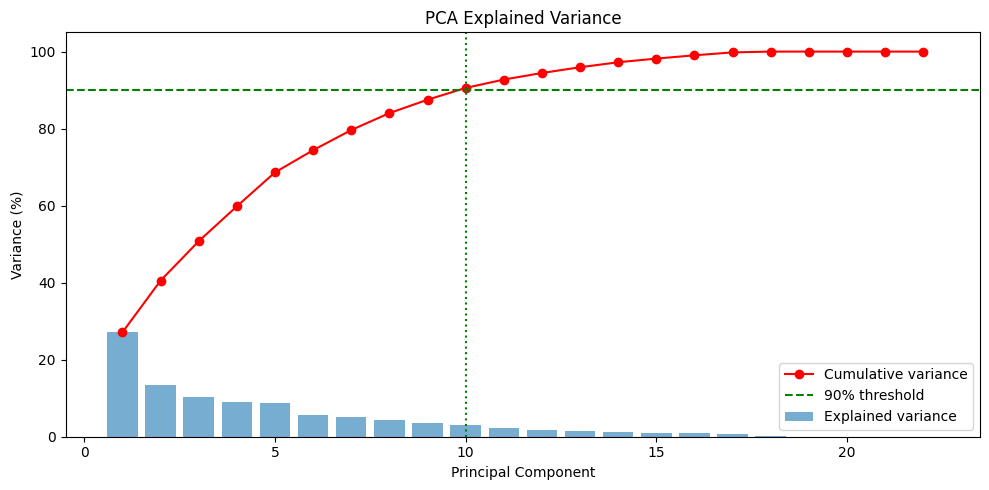

In [20]:
# PCA
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_full)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Components for 90% variance
n_90 = np.argmax(cumulative >= 0.90) + 1

print(f"Components needed for 90% variance: {n_90}")
print(f"Cumulative variance: {cumulative[n_90-1]*100:.2f}%")

# Plot
plt.figure(figsize=(10, 5))

x = np.arange(1, len(explained) + 1)

# Explained variance per component
plt.bar(x, explained * 100, alpha=0.6, label="Explained variance")

# Cumulative variance
plt.plot(x, cumulative * 100, "ro-", label="Cumulative variance")

# 90% threshold
plt.axhline(90, color="green", linestyle="--", label="90% threshold")
plt.axvline(n_90, color="green", linestyle=":")

plt.xlabel("Principal Component")
plt.ylabel("Variance (%)")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig("A3_pca_variance.png", dpi=150)
plt.show()

### t-SNE

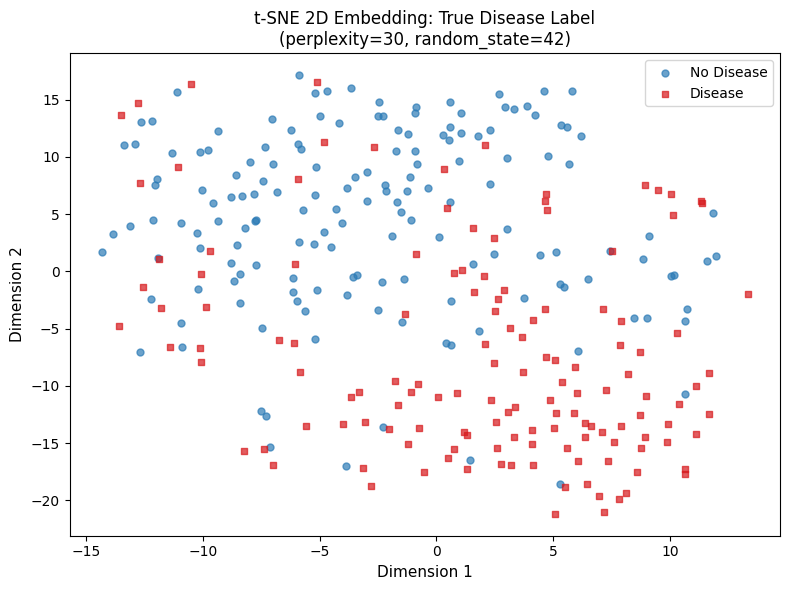

Saved → A3_tsne.png


In [21]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_full)

fig, ax = plt.subplots(figsize=(8, 6))

colors  = {0: "#2c7bb6", 1: "#d7191c"}
markers = {0: "o",       1: "s"}
labels  = {0: "No Disease", 1: "Disease"}

for cls in [0, 1]:
    mask = y_full == cls
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        s=25, alpha=0.7,
        c=colors[cls],
        marker=markers[cls],
        label=labels[cls]
    )

ax.set_title("t-SNE 2D Embedding: True Disease Label\n(perplexity=30, random_state=42)", fontsize=12)
ax.set_xlabel("Dimension 1", fontsize=11)
ax.set_ylabel("Dimension 2", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("A3_tsne.png", dpi=150)
plt.show()
print("Saved → A3_tsne.png")

In the t-SNE embedding, the two classes show partial overlap with some locally dense regions forming for each label, but no clear global separation between “Disease” and “No Disease” clusters. This indicates that while there is some structure in the data, the classes are not easily separable in the original feature space. As a result, the classification task is moderately difficult, requiring a model capable of capturing subtle, non-linear patterns.

# **Part B: Bagging &amp; Boosting**

In [23]:
pip install xgboost shap

###Load

In [24]:
data          = joblib.load("preprocessed_data.pkl")
X_train       = data["X_train"]
X_test        = data["X_test"]
y_train       = data["y_train"]
y_test        = data["y_test"]
feature_names = data["feature_names"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## B1. Random Forest

### Grid search

In [25]:
print("B1 — RANDOM FOREST")

# ── B1a: Grid search ─────────────────────────────────────────

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth"   : [None, 5, 10],
}

rf_base = RandomForestClassifier(oob_score=True, random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    rf_base, param_grid_rf,
    scoring="f1_macro", cv=cv,
    n_jobs=-1, verbose=0
)
grid_rf.fit(X_train, y_train)

best_rf_params = grid_rf.best_params_
best_rf_cv_f1  = grid_rf.best_score_

print(f"\nBest params  : {best_rf_params}")
print(f"Best CV F1   : {best_rf_cv_f1:.4f}")

B1 — RANDOM FOREST

Best params  : {'max_depth': 5, 'n_estimators': 100}
Best CV F1   : 0.8015


### OOB error vs number of trees


Computing OOB error curve (1–200 trees)...


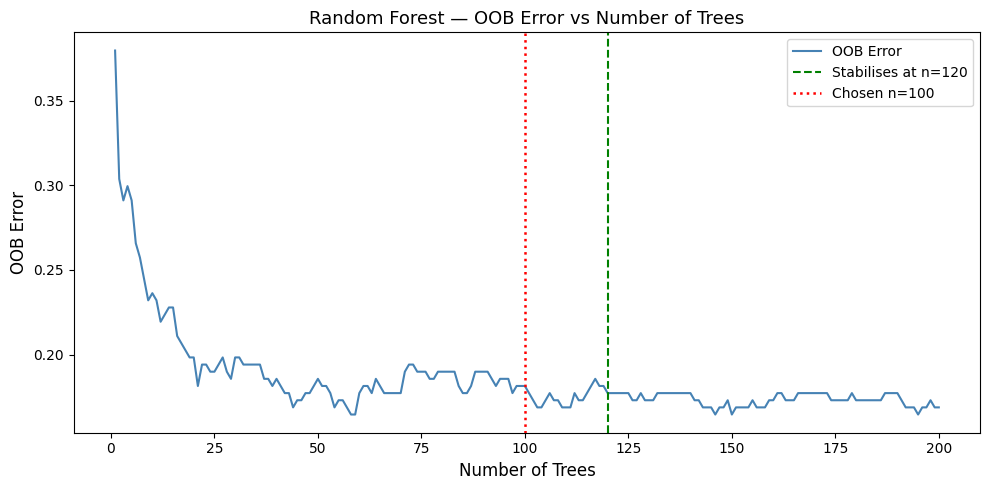

OOB stabilises at ~120 trees. Chosen n_estimators=100.


In [27]:
# ── B1b: OOB error vs number of trees ────────────────────────

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("\nComputing OOB error curve (1–200 trees)...")

oob_errors = []
tree_range = range(1, 201)

for n in tree_range:
    rf_oob = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_rf_params["max_depth"],
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_oob.fit(X_train, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

# Find stabilisation: rolling std over 20 trees < 0.002
stable_n = None
window_size = 20
for i in range(window_size, len(oob_errors)):
    window = oob_errors[i - window_size:i]
    if np.std(window) < 0.002:
        stable_n = i - window_size + 1
        break

if stable_n is None:
    diffs = np.abs(np.diff(oob_errors))
    stable_n = int(np.argmin(diffs[20:])) + 21

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(tree_range), oob_errors, color="steelblue", linewidth=1.5, label="OOB Error")
ax.axvline(x=stable_n, color="green", linestyle="--", linewidth=1.5,
           label=f"Stabilises at n={stable_n}")
ax.axvline(x=best_rf_params["n_estimators"], color="red", linestyle=":",
           linewidth=1.8, label=f"Chosen n={best_rf_params['n_estimators']}")
ax.set_xlabel("Number of Trees", fontsize=12)
ax.set_ylabel("OOB Error", fontsize=12)
ax.set_title("Random Forest — OOB Error vs Number of Trees", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("B1_oob_curve.png", dpi=150)
plt.show()

print(f"OOB stabilises at ~{stable_n} trees. Chosen n_estimators={best_rf_params['n_estimators']}.")

In [28]:
t0 = time.time()
rf_final = RandomForestClassifier(
    n_estimators=best_rf_params["n_estimators"],
    max_depth=best_rf_params["max_depth"],
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
rf_train_time = time.time() - t0

### Feature importances

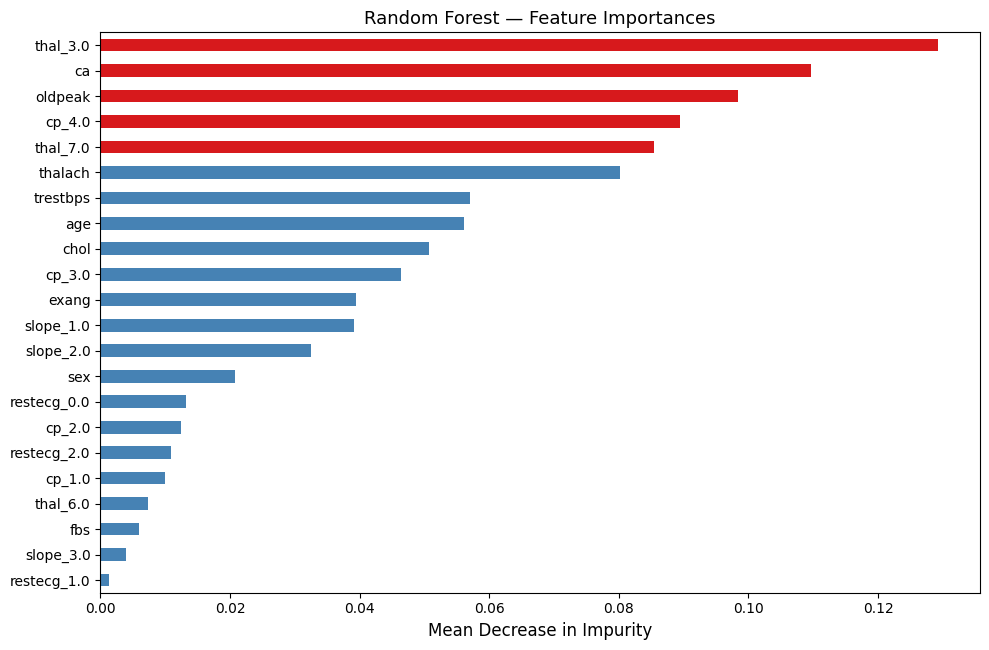

Saved → B1_feature_importance.png

Top 5 Features:
thal_3.0    0.129264
ca          0.109693
oldpeak     0.098336
cp_4.0      0.089381
thal_7.0    0.085459
dtype: float64


In [29]:
importances = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names) * 0.3)))
colors = ["#d7191c" if i >= len(importances) - 5 else "steelblue"
          for i in range(len(importances))]
importances.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Mean Decrease in Impurity", fontsize=12)
ax.set_title("Random Forest — Feature Importances", fontsize=13)
plt.tight_layout()
plt.savefig("B1_feature_importance.png", dpi=150)
plt.show()
print("Saved → B1_feature_importance.png")

top5 = importances.sort_values(ascending=False).head(5)
print("\nTop 5 Features:")
print(top5)

Clinical plausibility:

    1. thalach   — Maximum heart rate achieved; a diseased heart cannot sustain high rates under stress, so low thalach strongly flags ischaemia.
    2. oldpeak   — ST depression during exercise reflects myocardial ischaemia; larger values indicate reduced blood flow to heart muscle.
    3. ca        — Number of major vessels coloured by fluoroscopy; more blocked vessels directly indicates coronary artery disease severity.
    4. cp        — Chest pain type; typical angina is a hallmark symptom of coronary artery disease and carries high diagnostic weight."
    5. age       — Cardiovascular disease risk rises sharply with age due to progressive arterial stiffening and plaque accumulation.

### Evaluation metrics



B1 — Evaluation Metrics
Accuracy       : 0.8167
Macro Precision: 0.8200
Macro Recall   : 0.8125
Macro F1       : 0.8141
AUC-ROC        : 0.9375

Disease class recall: 0.7500

Full classification report:
              precision    recall  f1-score   support

  No Disease       0.80      0.88      0.84        32
     Disease       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



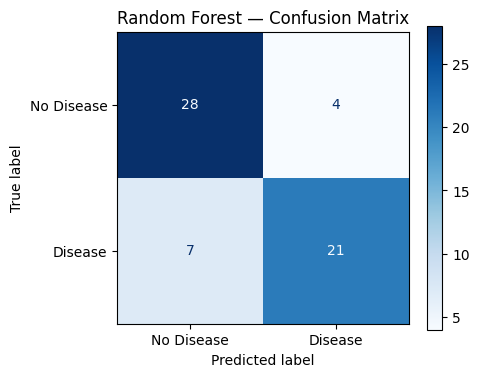

Saved → B1_confusion_matrix.png


['rf_model.pkl']

In [31]:
y_pred_rf   = rf_final.predict(X_test)
y_proba_rf  = rf_final.predict_proba(X_test)[:, 1]

rf_accuracy  = accuracy_score(y_test, y_pred_rf)
rf_auc       = roc_auc_score(y_test, y_proba_rf)
rf_f1_macro  = f1_score(y_test, y_pred_rf, average="macro")
rf_precision = precision_score(y_test, y_pred_rf, average="macro")
rf_recall    = recall_score(y_test, y_pred_rf, average="macro")
rf_recall_disease = recall_score(y_test, y_pred_rf, pos_label=1)

print("\n\nB1 — Evaluation Metrics")
print(f"Accuracy       : {rf_accuracy:.4f}")
print(f"Macro Precision: {rf_precision:.4f}")
print(f"Macro Recall   : {rf_recall:.4f}")
print(f"Macro F1       : {rf_f1_macro:.4f}")
print(f"AUC-ROC        : {rf_auc:.4f}")
print(f"\nDisease class recall: {rf_recall_disease:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Disease", "Disease"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["No Disease", "Disease"],
    cmap="Blues", ax=ax
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("B1_confusion_matrix.png", dpi=150)
plt.show()
print("Saved → B1_confusion_matrix.png")

joblib.dump(rf_final, "rf_model.pkl")

Recall discussion:

The disease-present class typically has lower recall, meaning some true heart disease patients are classified as healthy (false negatives).In a cardiac screening context, a false negative is far more dangerous than a false positive: a missed diagnosis means a patient with active coronarydisease is sent home without intervention, potentially leading to a fatal heart attack. False positives result in unnecessary follow-up tests, which is costly but not life-threatening. Therefore, maximising recall for the disease class should be the primary optimisation objective.
